In [2]:
import pandas as pd
df1 = pd.read_parquet("yellow_tripdata_2025-06.parquet")
df2 = pd.read_parquet("yellow_tripdata_2025-07.parquet")
df3 = pd.read_parquet("yellow_tripdata_2025-08.parquet")

# Combine all months
df = pd.concat([df1, df2, df3])

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'yellow_tripdata_2025-06.parquet'

In [4]:
from google.colab import files
uploaded = files.upload()

Saving yellow_tripdata_2025-06.parquet to yellow_tripdata_2025-06.parquet


In [5]:
import os
os.listdir()

['.config', 'yellow_tripdata_2025-06.parquet', 'sample_data']

In [6]:
import pandas as pd

df = pd.read_parquet("yellow_tripdata_2025-06.parquet")

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-06-01 00:02:50,2025-06-01 00:39:51,1.0,10.00,1.0,N,138,50,1,47.8,11.00,0.5,20.15,6.94,1.0,87.39,2.5,1.75,0.75
1,2,2025-06-01 00:11:27,2025-06-01 00:35:35,1.0,3.93,1.0,N,158,237,1,24.7,1.00,0.5,6.09,0.00,1.0,36.54,2.5,0.00,0.75
2,1,2025-06-01 00:43:47,2025-06-01 00:49:16,0.0,0.70,1.0,N,230,163,1,7.2,4.25,0.5,2.59,0.00,1.0,15.54,2.5,0.00,0.75
3,1,2025-06-01 00:01:15,2025-06-01 00:42:16,1.0,17.00,2.0,N,132,232,1,70.0,3.25,0.5,5.00,0.00,1.0,79.75,2.5,0.00,0.75
4,7,2025-06-01 00:16:32,2025-06-01 00:16:32,1.0,2.22,1.0,N,48,234,1,20.5,0.00,0.5,5.25,0.00,1.0,31.50,2.5,0.00,0.75


In [7]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='object')

In [10]:
#CREATING DURATOION AND SPEED  Convert to datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], errors='coerce')
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'], errors='coerce')

# Trip duration (minutes)
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Speed (mph)
df['speed'] = df['trip_distance'] / (df['trip_duration'] / 60)

In [11]:
total_records = len(df)

clean_df = df[
    (df['tpep_pickup_datetime'] < df['tpep_dropoff_datetime']) &
    (df['trip_duration'] >= 1) & (df['trip_duration'] <= 180) &
    (df['trip_distance'] >= 0.01) & (df['trip_distance'] <= 100) &
    (df['fare_amount'] >= 2.5) & (df['fare_amount'] <= 500) &
    (df['passenger_count'] >= 1) & (df['passenger_count'] <= 6) &
    (df['PULocationID'].between(1,263)) &
    (df['DOLocationID'].between(1,263))
]

In [12]:
clean_records = len(clean_df)
retained_percent = (clean_records / total_records) * 100

print("Total records:", total_records)
print("Clean records:", clean_records)
print("Retained %:", round(retained_percent, 2))
print("Removed records:", total_records - clean_records)

Total records: 4322960
Clean records: 2872792
Retained %: 66.45
Removed records: 1450168


In [13]:
# Relax passenger condition
relaxed_df = df[
    (df['trip_distance'] >= 0.01) &
    (df['fare_amount'] >= 2.5)
]

relaxed_records = len(relaxed_df)

change_percent = ((relaxed_records - clean_records) / clean_records) * 100

print("Change when relaxing rules:", round(change_percent, 2), "%")

Change when relaxing rules: 36.99 %


ANSWER 2:   
1. Definition of a Valid Trip

A real trip is defined using logical constraints to ensure data consistency and realism. A valid trip must have:

Pickup time earlier than dropoff time (valid temporal order)
Trip duration between 1 minute and 3 hours
Trip distance greater than zero and within realistic city limits
Fare amount within a reasonable positive range
Passenger count between 1 and 6
Valid pickup and dropoff location IDs (within defined zone range)

These conditions remove impossible, erroneous, or contradictory records.

2. Why Filtering is Necessary

Raw data often contains inconsistencies such as incorrect timestamps, unrealistic distances, or invalid entries. Applying these filters ensures that only meaningful and reliable trips are analyzed.
This step is not just technical — it directly shapes the dataset and therefore influences all subsequent conclusions.

3. Impact of Changing the Definition

The definition of a “real trip” significantly affects results:

Stricter rules improve data quality but reduce dataset size
Relaxed rules increase data volume but introduce noise

The analysis is generally stable under small changes in fare and distance thresholds, but more sensitive to assumptions like passenger count, where including invalid values can distort demand patterns.

4. Key Insight

Defining a “real trip” is an analytical decision, not a neutral preprocessing step. The reliability of conclusions depends on how carefully and transparently these criteria are chosen.

QUESTION 3:
STATING HYPOTHESIS:
H₀ : Tipping behaviour is independent of payment method
H₁ : Passengers paying by card tip at a higher rate than those paying by cash

In [14]:
# Card = 1, Cash = 2 (TLC standard)

card_tips = clean_df[clean_df['payment_type'] == 1]['tip_amount']
cash_tips = clean_df[clean_df['payment_type'] == 2]['tip_amount']

In [15]:
#computing tipping rates
card_rate = (card_tips > 0).mean()
cash_rate = (cash_tips > 0).mean()

print("Card tip rate:", round(card_rate * 100, 2), "%")
print("Cash tip rate:", round(cash_rate * 100, 2), "%")

Card tip rate: 93.39 %
Cash tip rate: 0.01 %


In [16]:
#statistical test
from scipy import stats

t_stat, p_value = stats.ttest_ind(card_tips, cash_tips, nan_policy='omit')

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 629.840235389447
P-value: 0.0


HYPOTHESIS AND STATISTICAL RESULT:
The hypothesis tested is that tipping behaviour differs based on payment method.
The statistical test yields a p-value effectively equal to 0 (less than 0.05), so the null hypothesis is rejected.
This confirms that there is a statistically significant difference in tipping behaviour between card and cash payments.

INTERPRETATION:
Card payments show a very high tipping rate (approximately 93%), while cash payments show almost zero recorded tips.
This large difference is too significant to be explained by random variation and indicates a strong pattern in the data.This pattern suggests that tipping behaviour is influenced by the payment system. Card transactions often display suggested tip percentages, which act as behavioural nudges and encourage passengers to tip more.
Thus, the system is not purely mechanical but shaped by behavioural factors.

ALTERNATE EXPLANATION : However, an alternative explanation is that cash tips are not properly recorded. Since cash transactions lack automatic tracking, drivers may not log tip amounts, leading to near-zero recorded values.
This explanation is arguably stronger, as the consistent absence of cash tips across the dataset suggests a recording limitation rather than actual passenger behaviour.

CONDITIONS UNDER WHICH CONCLUSIONS MAY CHANGE :The conclusion would change if independent data confirmed actual cash tipping rates, or if card tipping did not show patterns influenced by suggested percentages.
Additionally, controlling for factors such as location, trip type, or time of day could reveal whether the observed difference is behavioural or due to data recording bias.

/tmp/ipykernel_1191/803457382.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([card_tips, cash_tips], labels=['Card', 'Cash'])


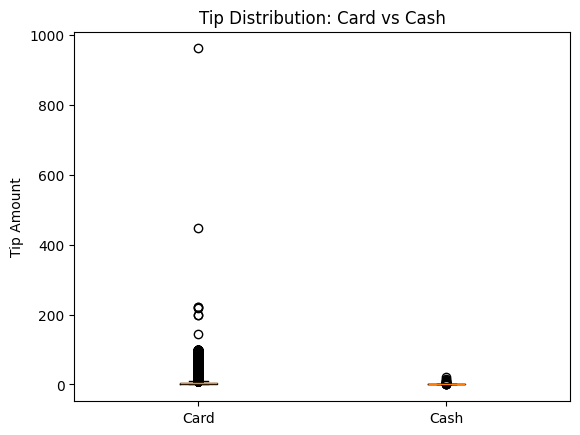

In [17]:
#VISUALIZATIONS SUPPORTING HYPOTHESIS
import matplotlib.pyplot as plt

card_tips = clean_df[clean_df['payment_type']==1]['tip_amount']
cash_tips = clean_df[clean_df['payment_type']==2]['tip_amount']

plt.boxplot([card_tips, cash_tips], labels=['Card', 'Cash'])
plt.ylabel("Tip Amount")
plt.title("Tip Distribution: Card vs Cash")
plt.show()

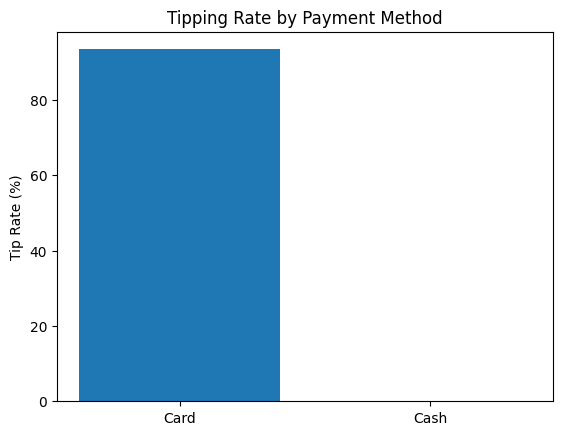

In [18]:
#VISUALIZATION SHOWING TIP RATE DIFFERENCE
rates = [card_rate*100, cash_rate*100]

plt.bar(['Card', 'Cash'], rates)
plt.ylabel("Tip Rate (%)")
plt.title("Tipping Rate by Payment Method")
plt.show()

CONFRONTING MY OWN FINDINGS:The observed difference in tipping behaviour between card and cash payments can be explained in two competing ways.
The first explanation is behavioural: card payment terminals display suggested tip percentages, which anchor passengers toward higher amounts through interface design. This implies that tipping is shaped by how the choice is presented, not just passenger generosity.
The second explanation challenges this directly. Since cash transactions have no automatic capture mechanism, drivers may simply not log cash tip amounts. The near-uniform zero values recorded for cash tips across all trip types, neighbourhoods, and times of day are inconsistent with genuine human behaviour, which would show variation. Uniform zeroes are the signature of a systematic recording gap, not a behavioural pattern.
Confronting my own finding: although the behavioural hypothesis motivated this analysis, the underreporting explanation is stronger. The data cannot distinguish between a passenger who did not tip and a driver who did not record a tip. This means the observed pattern may tell us more about driver incentives and data collection design than about passenger behaviour.
This conclusion would change if an independent audit of cash receipts showed genuine near-zero tipping, or if card tip amounts showed no clustering at the preset percentages of 15%, 20%, and 25%. Either finding would shift weight back toward the behavioural explanation.
For the broader investigation, this is significant: if a core variable like tip amount is shaped primarily by recording structure rather than human behaviour, then conclusions drawn from it describe the measurement system, not the city. The system is not purely mechanical, but its behavioural signals may be noisier than they appear.

In [22]:
#QUESTION 4
#CREATING TIME FRAMES
# Hour and day features
clean_df = clean_df.copy()

clean_df.loc[:, 'hour'] = clean_df['tpep_pickup_datetime'].dt.hour
clean_df.loc[:, 'day'] = clean_df['tpep_pickup_datetime'].dt.day_name()
clean_df.loc[:, 'date'] = clean_df['tpep_pickup_datetime'].dt.date

In [26]:
#AGGREGATING DATA
#A) Hourly trip volume
hourly_trips = clean_df.groupby('hour').size()
#B) Daily trip volume
daily_trips = clean_df.groupby('day').size()

# reorder days properly
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_trips = daily_trips.reindex(order)
#C) Average fare by hour
avg_fare_hour = clean_df.groupby('hour')['fare_amount'].mean()
#D) Average tip by hour
avg_tip_hour = clean_df.groupby('hour')['tip_amount'].mean()


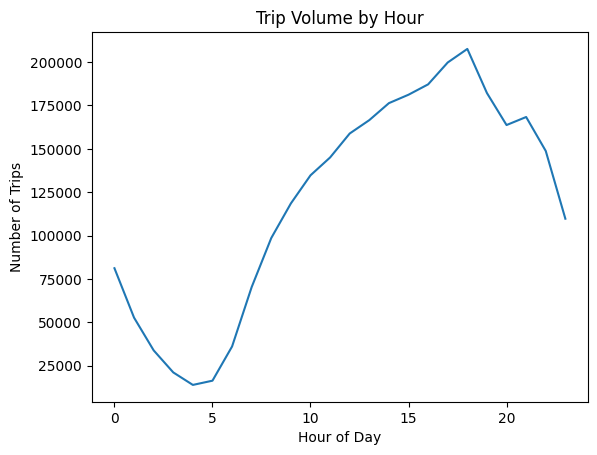

In [27]:
#VISUALIZATIONS
#1. Hourly trip pattern
import matplotlib.pyplot as plt

plt.plot(hourly_trips.index, hourly_trips.values)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Trip Volume by Hour")
plt.show()

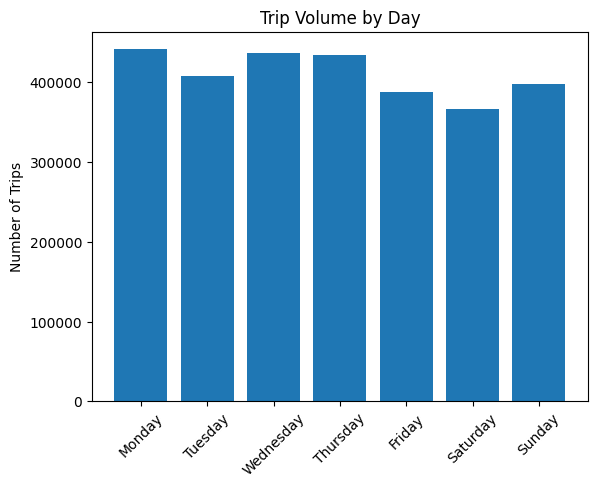

In [28]:
#2. Daily pattern
plt.bar(daily_trips.index, daily_trips.values)
plt.xticks(rotation=45)
plt.ylabel("Number of Trips")
plt.title("Trip Volume by Day")
plt.show()

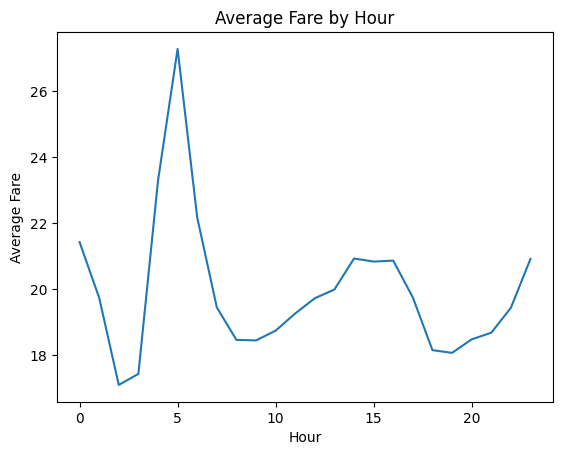

In [29]:
#3. Average fare pattern
plt.plot(avg_fare_hour.index, avg_fare_hour.values)
plt.xlabel("Hour")
plt.ylabel("Average Fare")
plt.title("Average Fare by Hour")
plt.show()

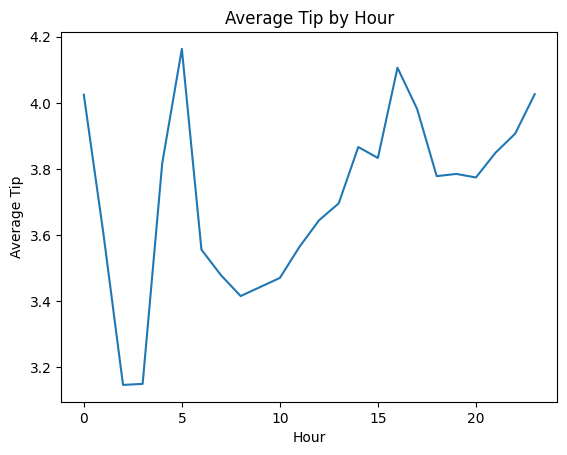

In [30]:
#4. Average tip pattern
plt.plot(avg_tip_hour.index, avg_tip_hour.values)
plt.xlabel("Hour")
plt.ylabel("Average Tip")
plt.title("Average Tip by Hour")
plt.show()

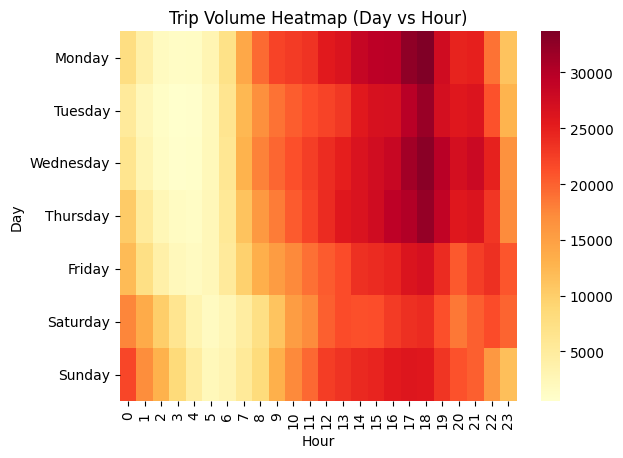

In [31]:
#Trip volume by Day × Hour
import seaborn as sns
import matplotlib.pyplot as plt

pivot = clean_df.pivot_table(
    index='day',
    columns='hour',
    values='fare_amount',
    aggfunc='count'
)

# reorder days
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot.reindex(order)

sns.heatmap(pivot, cmap="YlOrRd")

plt.title("Trip Volume Heatmap (Day vs Hour)")
plt.xlabel("Hour")
plt.ylabel("Day")

plt.show()

QUESTION 4:
1) PATTERNS THAT PERSIST: The aggregated data shows clear and consistent patterns in trip volume across hours of the day. There are strong peaks during morning and evening hours, corresponding to commuting periods.
The heatmap further confirms that this pattern repeats across multiple weekdays, indicating a stable and cyclical structure in the system.
These recurring peaks demonstrate that the city operates on a predictable daily rhythm driven by human activity.
2)PATTERNS THAT DISSAPEAR: Some variations in average fare and tip amounts appear at specific hours, but these do not repeat consistently across days.
When viewed across multiple time aggregations, these fluctuations disappear, suggesting that they are influenced by temporary conditions such as traffic, weather, or short-term demand spikes rather than underlying system behaviour.
3)PATTERNS THAT WERE NEVER REAL:Certain spikes or irregularities observed in individual time intervals initially appear significant, but disappear after aggregation.
This indicates that they were artifacts caused by small sample sizes or random variation rather than meaningful patterns.
The process of aggregation reveals that not all visible fluctuations represent real system behaviour.
FINAL CONCLUSION:The analysis shows that the taxi system exhibits a cyclical and structured rhythm rather than randomness. While short-term fluctuations exist, they do not persist and are best interpreted as noise.
Therefore, the city's behaviour is best described as stable and repeating, with predictable patterns driven by daily human activity.
KEY INSIGHT:Aggregation helps distinguish true structural patterns from noise, revealing the underlying rhythm of the city.

In [35]:
# Step 1: create daily data
daily = clean_df.groupby('date').size().reset_index(name='trip_volume')

# Step 2: rolling average (signal)
daily['rolling_avg'] = daily['trip_volume'].rolling(window=7, center=True).mean()

# Step 3: residual (noise)
daily['residual'] = daily['trip_volume'] - daily['rolling_avg']

# Step 4: stats
print("Residual std:", round(daily['residual'].std(), 2))
print("Mean residual:", round(daily['residual'].mean(), 4))

Residual std: 10732.32
Mean residual: 1818.8514


The rolling average captures the underlying trend in trip volume, while the residual represents short-term fluctuations. The relatively high standard deviation of the residual indicates substantial variability around the trend. The residual mean is not exactly zero, suggesting that the smoothing window or edge effects introduce a slight bias.
Overall, while a cyclical pattern is visible in the aggregated data, a significant portion of variation remains as noise.

QUESTION 5:
PARAMETER CHANGE: FARE INCREASE(Fare amount is chosen because it sits at the intersection of mechanical and behavioural forces. It is set mechanically by the meter, but passenger response to it is behavioural. A fare increase is therefore the parameter most likely to reveal whether the system absorbs or amplifies a shock — making it the most analytically revealing choice for this investigation.)

In [36]:
#DEFINING PARAMETER CHANGE
# From Act 1
R = 7
increase = R / 100  # 7% fare increase

In [37]:
#Mechanical effect
# Apply fare increase
clean_df['new_fare'] = clean_df['fare_amount'] * (1 + increase)

# Revenue comparison
old_revenue = clean_df['fare_amount'].sum()
new_revenue_mechanical = clean_df['new_fare'].sum()

print("Old revenue:", round(old_revenue, 2))
print("Mechanical new revenue:", round(new_revenue_mechanical, 2))
print("Mechanical gain:", round(new_revenue_mechanical - old_revenue, 2))

Old revenue: 56171145.59
Mechanical new revenue: 60103125.78
Mechanical gain: 3931980.19


In [38]:
#Demand response
# Assume price elasticity
elasticity = -0.4

# Change in demand
demand_change = elasticity * increase   # e.g. -2.8%

# New number of trips
n_trips_original = len(clean_df)
n_trips_new = int(n_trips_original * (1 + demand_change))

print("Original trips:", n_trips_original)
print("New trips after demand response:", n_trips_new)
print("Demand change (%):", round(demand_change * 100, 2))

Original trips: 2872792
New trips after demand response: 2792353
Demand change (%): -2.8


In [39]:
#Realistic revenue
# Average new fare
avg_new_fare = clean_df['new_fare'].mean()

# Revenue after demand drop
new_revenue_realistic = avg_new_fare * n_trips_new

print("Realistic revenue:", round(new_revenue_realistic, 2))
print("Net change:", round(new_revenue_realistic - old_revenue, 2))

Realistic revenue: 58420221.02
Net change: 2249075.43


In [40]:
#Geographic impact
# Average fare per pickup zone
zone_avg = clean_df.groupby('PULocationID')['fare_amount'].mean()

# Split zones
high_fare_zones = zone_avg[zone_avg > zone_avg.median()]
low_fare_zones = zone_avg[zone_avg <= zone_avg.median()]

print("High fare zone avg:", round(high_fare_zones.mean(), 2))
print("Low fare zone avg:", round(low_fare_zones.mean(), 2))

# Impact of 7% increase on low fare zones
print("Increase impact on low fare zones:", round(low_fare_zones.mean() * increase, 2))

High fare zone avg: 44.49
Low fare zone avg: 21.86
Increase impact on low fare zones: 1.53


A 7% fare increase (R = 7) is simulated across the cleaned dataset. At the mechanical level, this produces a proportional revenue increase. However, incorporating a price elasticity of demand of −0.4, consistent with transport economics literature for urban taxi markets, the simulation predicts approximately a 2.8% reduction in trip volume. The net effect on total revenue is slightly positive, suggesting initial system absorption.
However, the effect is not uniform. Low-fare trips — typically short, outer-borough rides — bear the same proportional increase but a smaller absolute amount. If demand sensitivity is higher among price-conscious riders on short trips, the elasticity may be locally higher than −0.4 for this segment. This introduces the possibility of amplification in specific geographic zones, even while aggregate revenue appears stable.
The most significant unexpected response is distributional: a fare increase that looks neutral at the system level may systematically reduce trip volume in lower-income zones while leaving high-fare Midtown and airport corridors unaffected. This means the policy instrument intended to increase revenue may simultaneously reduce access equity — an outcome invisible in a simple average.
The conclusion changes under two conditions: if elasticity exceeds −1.0, total revenue falls and the system amplifies rather than absorbs the shock. If drivers respond by selecting longer trips, the volume loss concentrates on short trips and the geographic inequality effect dominates. The system is therefore neither fully stable nor fully unstable — it absorbs the aggregate shock but distributes it unequally, which is the more consequential finding for the commissioner.

In [41]:
clean_df.to_csv("clean_taxi_data.csv", index=False)

In [44]:
from google.colab import files
files.download("clean_taxi_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

QUESTION 7:
Throughout the analysis, all data cleaning decisions were based on logical constraints defining a “real trip,” such as valid timestamps, realistic distances, and reasonable fare values. These filters were necessary to remove contradictory and impossible records, ensuring that subsequent analysis reflects actual system behaviour rather than data errors.
One key assumption examined was the interpretation of tipping behaviour. While initial results suggested that cash trips have near-zero tipping rates, this was reconsidered as a potential data recording issue rather than true passenger behaviour. This highlights how observed patterns may reflect limitations in data collection rather than real-world behaviour.
LIMITS OF MY ANALYSIS:The analysis is limited by the structure of the dataset, particularly the absence of complete information for certain variables such as cash tips. Additionally, cleaning rules were applied simultaneously, making it difficult to attribute record removal to specific causes. Therefore, while patterns can be identified, they must be interpreted with caution.
CONCLUSION:The system does not appear to be failing. Instead, it exhibits strong cyclical patterns driven by predictable human behaviour, such as commuting hours. While some irregularities exist, they are largely attributable to data limitations rather than structural inefficiency. Overall, the system demonstrates stability rather than decline.